This new dataset is about energy production 


I will perform analysis over it

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

In [2]:
energy = pd.read_csv("Energy Production Dataset.csv")
energy.sample(5)

,Date,Start_Hour,End_Hour,Source,Day_of_Year,Day_Name,Month_Name,Season,Production
21139,7/4/2023,7,8,Wind,185,Tuesday,July,Summer,1680
1225,10/10/2025,19,20,Wind,283,Friday,October,Fall,3099
1783,9/17/2025,14,15,Solar,260,Wednesday,September,Fall,13085
41570,3/4/2021,3,4,Wind,63,Thursday,March,Spring,1157
26547,11/20/2022,16,17,Wind,324,Sunday,November,Fall,9459


In [3]:
energy.shape

(51864, 9)

In [4]:
energy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51864 entries, 0 to 51863
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Date         51864 non-null  object
 1   Start_Hour   51864 non-null  int64 
 2   End_Hour     51864 non-null  int64 
 3   Source       51864 non-null  object
 4   Day_of_Year  51864 non-null  int64 
 5   Day_Name     51864 non-null  object
 6   Month_Name   51864 non-null  object
 7   Season       51864 non-null  object
 8   Production   51864 non-null  int64 
dtypes: int64(4), object(5)
memory usage: 3.6+ MB


In [5]:
energy.describe()

,Start_Hour,End_Hour,Day_of_Year,Production
count,51864.000000,51864.000000,51864.000000,51864.000000
mean,11.500000,11.500000,180.798415,6215.069933
std,6.922253,6.922253,104.291387,3978.364965
min,0.000000,0.000000,1.000000,58.000000
25%,5.750000,5.750000,91.000000,3111.000000
50%,11.500000,11.500000,181.000000,5372.000000
75%,17.250000,17.250000,271.000000,8501.000000
max,23.000000,23.000000,366.000000,23446.000000


The dataset initial impressions are 
1) The whole dataset is an ordinal dataset hence its a discrete data
2) We have to understand the dataset and find which parameters contribute towards more production

In [6]:
energy.isna().sum()

Date           0
Start_Hour     0
End_Hour       0
Source         0
Day_of_Year    0
Day_Name       0
Month_Name     0
Season         0
Production     0
dtype: int64

In [7]:
energy.sample(5)

,Date,Start_Hour,End_Hour,Source,Day_of_Year,Day_Name,Month_Name,Season,Production
45869,9/6/2020,8,9,Wind,250,Sunday,September,Fall,1543
27389,10/16/2022,4,5,Wind,289,Sunday,October,Fall,3203
33999,1/14/2022,7,8,Wind,14,Friday,January,Winter,961
38482,7/11/2021,15,16,Solar,192,Sunday,July,Summer,4877
25821,12/21/2022,10,11,Wind,355,Wednesday,December,Winter,8040


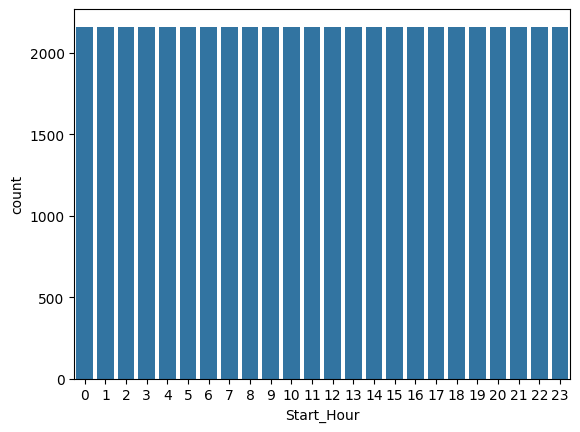

In [8]:
sns.countplot(data = energy, x = 'Start_Hour')
plt.show()

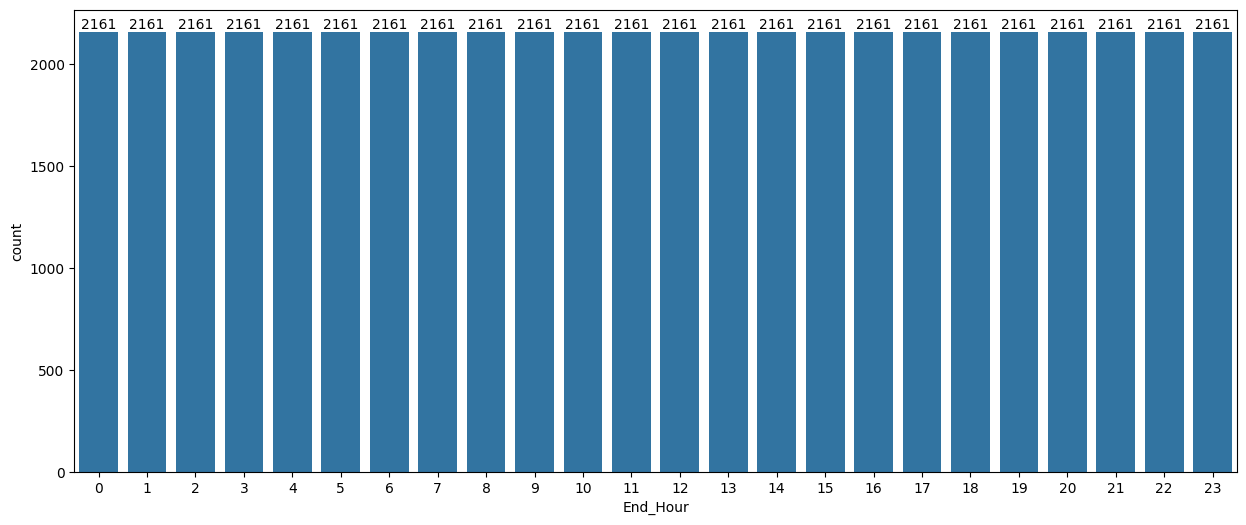

In [9]:
plt.figure(figsize=(15,6))
plot = sns.countplot(data = energy, x = 'End_Hour',)
plot.bar_label(plot.containers[0])
plt.show()

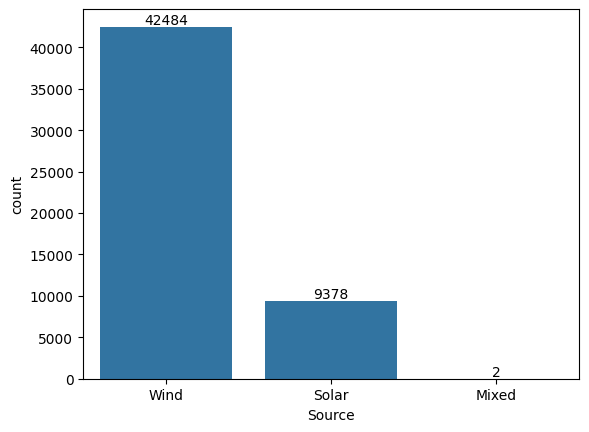

In [10]:
plot = sns.countplot(data = energy, x = 'Source')
plot.bar_label(plot.containers[0])
plt.show()

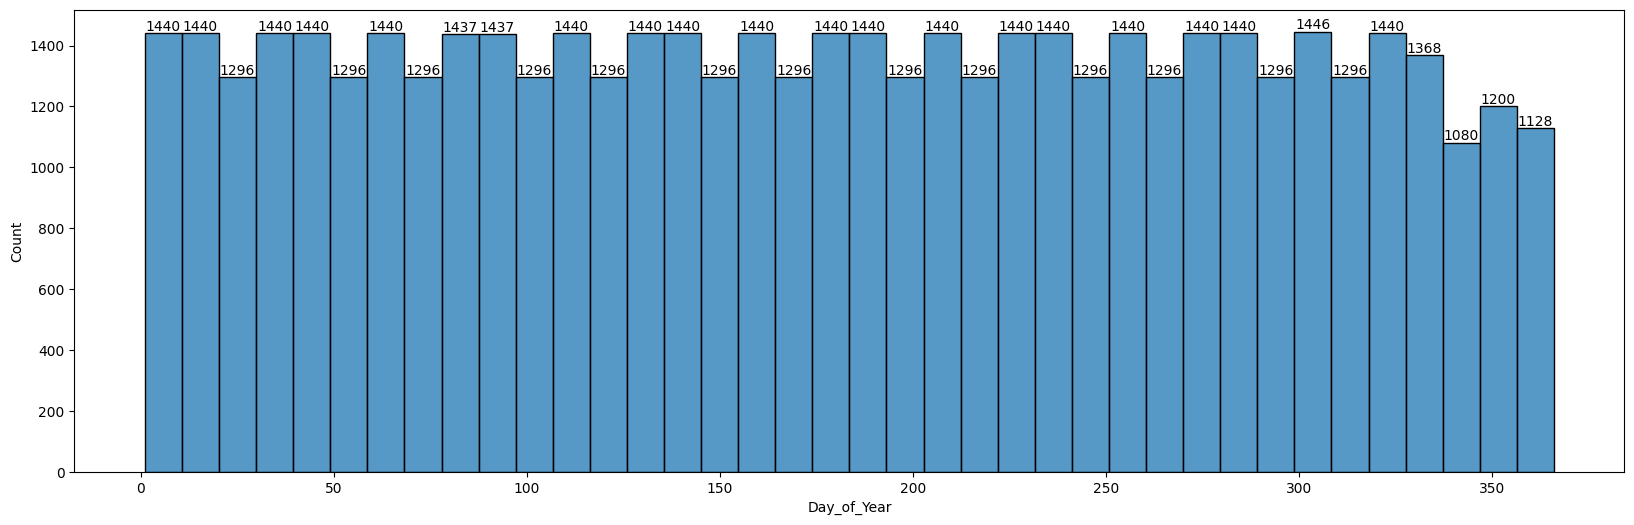

In [11]:
plt.figure(figsize=(20, 6))
plot = sns.histplot(data = energy, x = 'Day_of_Year')
plot.bar_label(plot.containers[0])
plt.show()

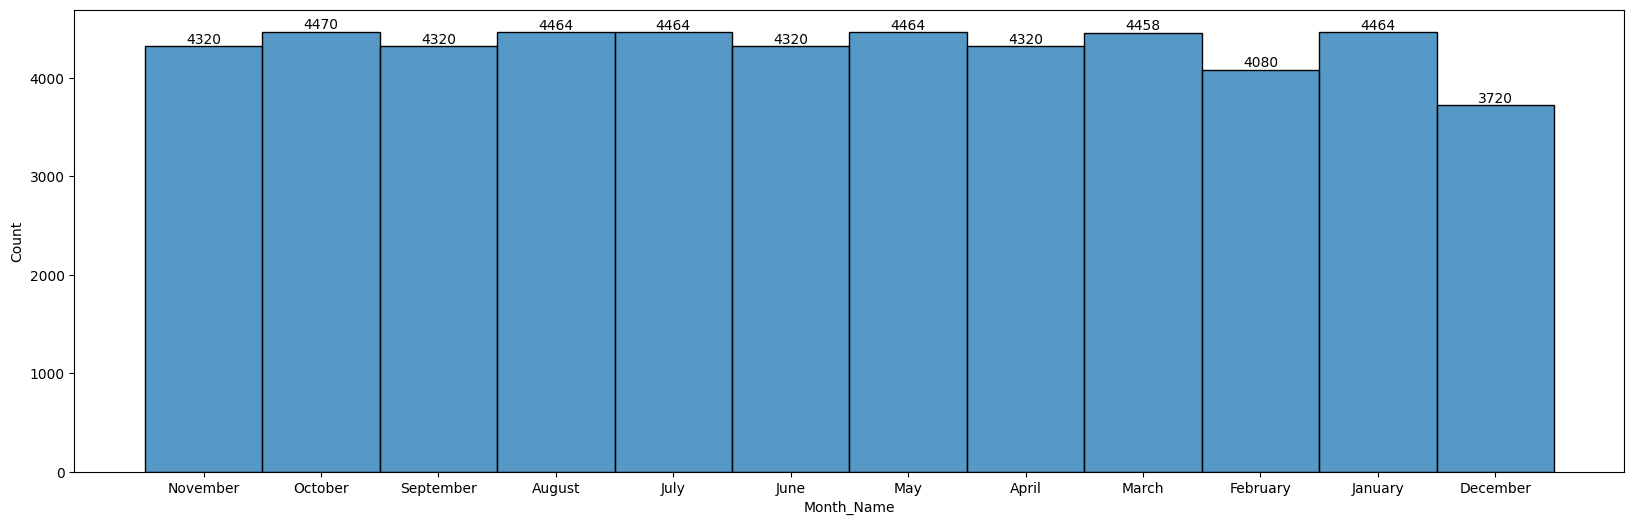

In [12]:
plt.figure(figsize=(20, 6))
plot = sns.histplot(data = energy, x = 'Month_Name')
plot.bar_label(plot.containers[0])
plt.show()

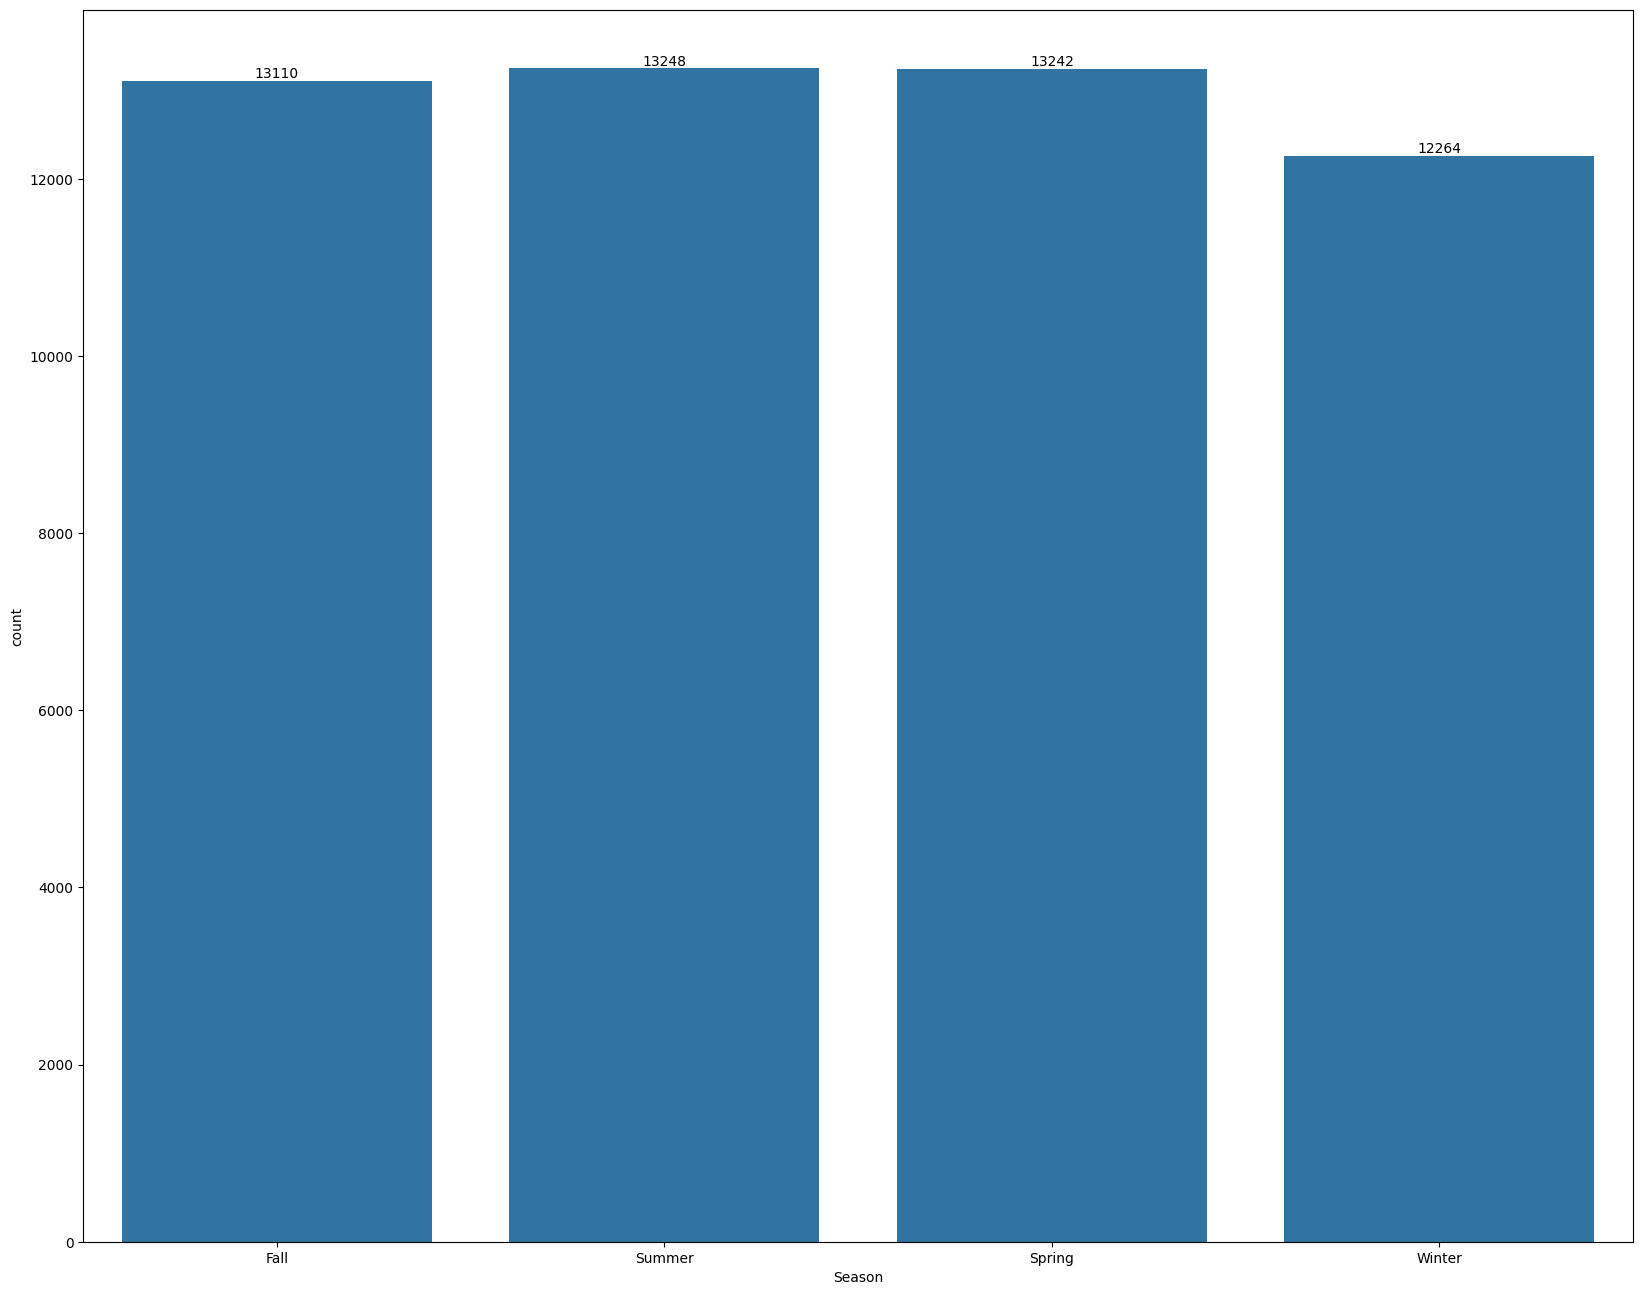

In [13]:
plt.figure(figsize=(20, 16))
plot = sns.countplot(data = energy, x = 'Season')
plot.bar_label(plot.containers[0])
plt.show()

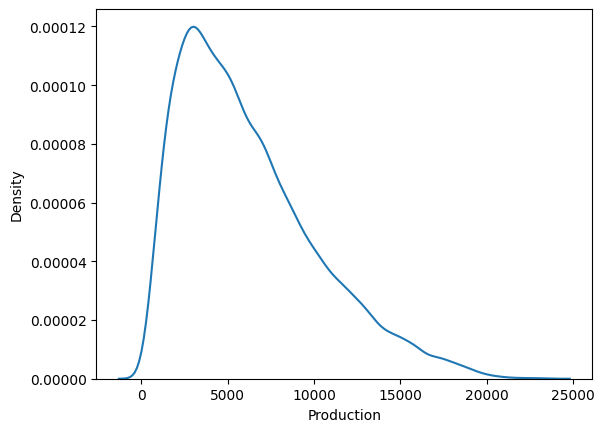

In [14]:
sns.kdeplot(data = energy, x = 'Production')
plt.show()

## Report after Univariate Analysis

1) The dataset is uniformly distributed i.e every column has equal rows in terms of Start_Hour and End_Hour
2) The dataset has Wind as its major source of energy production with count of 42484
3) The week name and day_of_Year is kind of useless cuz the natural resources wont be varying over week but instead season and month, but will verify in bivariate analysis
4) The dataset has major entries of Summer and Winter being the least
5) The Prodcution(Result Variable) follows a Gamma Distribution

In [15]:
energy.sample(5)

,Date,Start_Hour,End_Hour,Source,Day_of_Year,Day_Name,Month_Name,Season,Production
28604,8/27/2022,4,5,Wind,239,Saturday,August,Summer,2388
540,11/8/2025,20,21,Wind,312,Saturday,November,Fall,2783
9705,10/22/2024,18,19,Wind,296,Tuesday,October,Fall,1143
8740,12/1/2024,19,20,Wind,336,Sunday,December,Winter,7486
37396,8/25/2021,13,14,Wind,237,Wednesday,August,Summer,10108


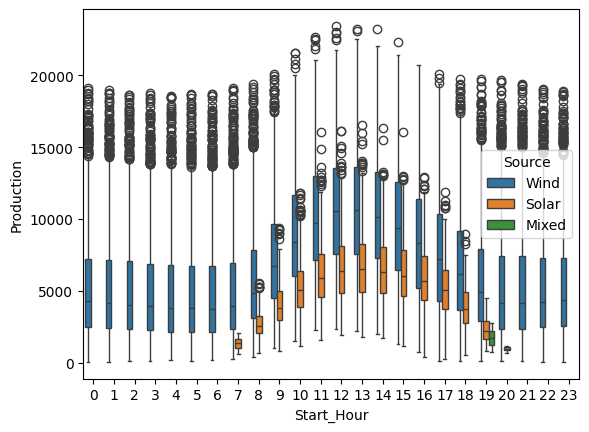

In [16]:
sns.boxplot(data = energy, x = 'Start_Hour', y = 'Production', hue = 'Source')
plt.show()

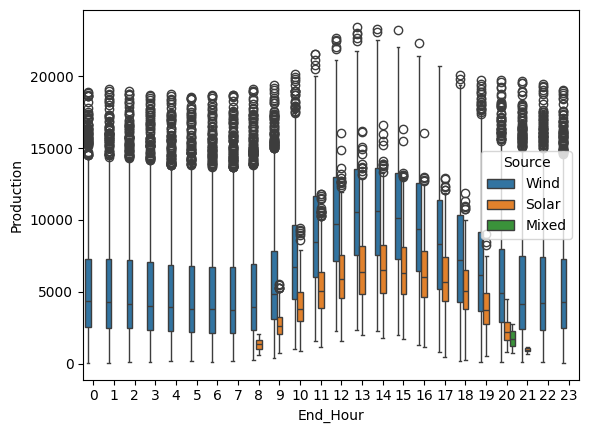

In [17]:
sns.boxplot(data = energy, x = 'End_Hour', y = 'Production', hue= 'Source')
plt.show()

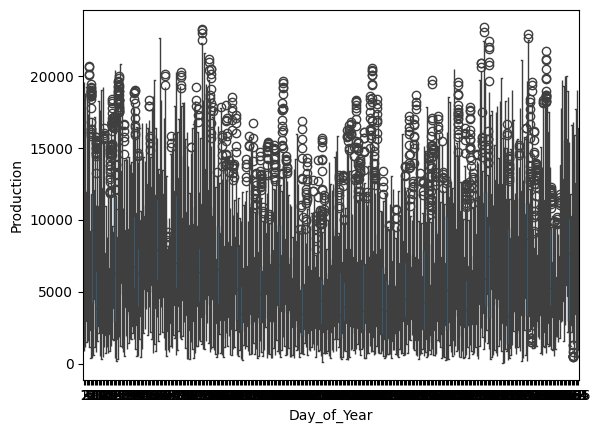

In [18]:
sns.boxplot(data = energy, x = 'Day_of_Year', y = 'Production')
plt.show()

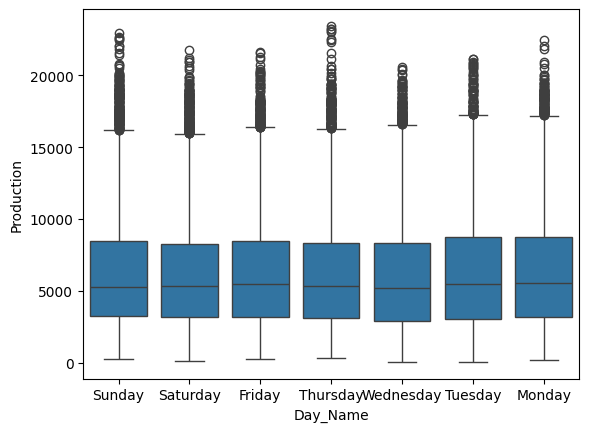

In [19]:
sns.boxplot(data = energy, x = 'Day_Name', y = 'Production')
plt.show()

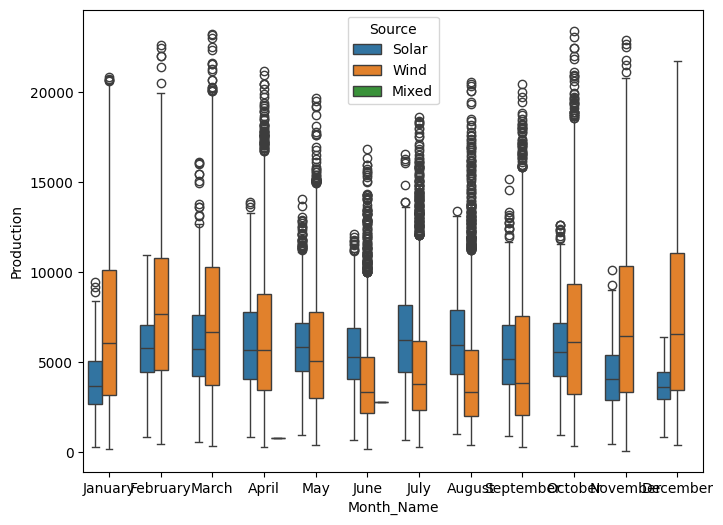

In [20]:
months_in_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
df = energy.copy(deep=True)
df['Month'] = pd.Categorical(df['Month_Name'], categories=months_in_order, ordered=True)
df = df.sort_values(by='Month')
plt.figure(figsize=(8, 6))
sns.boxplot(data = df, x = 'Month_Name', y = 'Production', hue = 'Source')
plt.show()

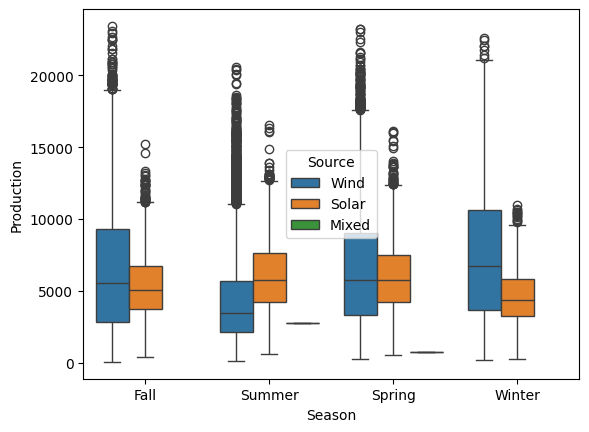

In [21]:
sns.boxplot(data = energy, x = 'Season', y = 'Production', hue = 'Source')
plt.show()

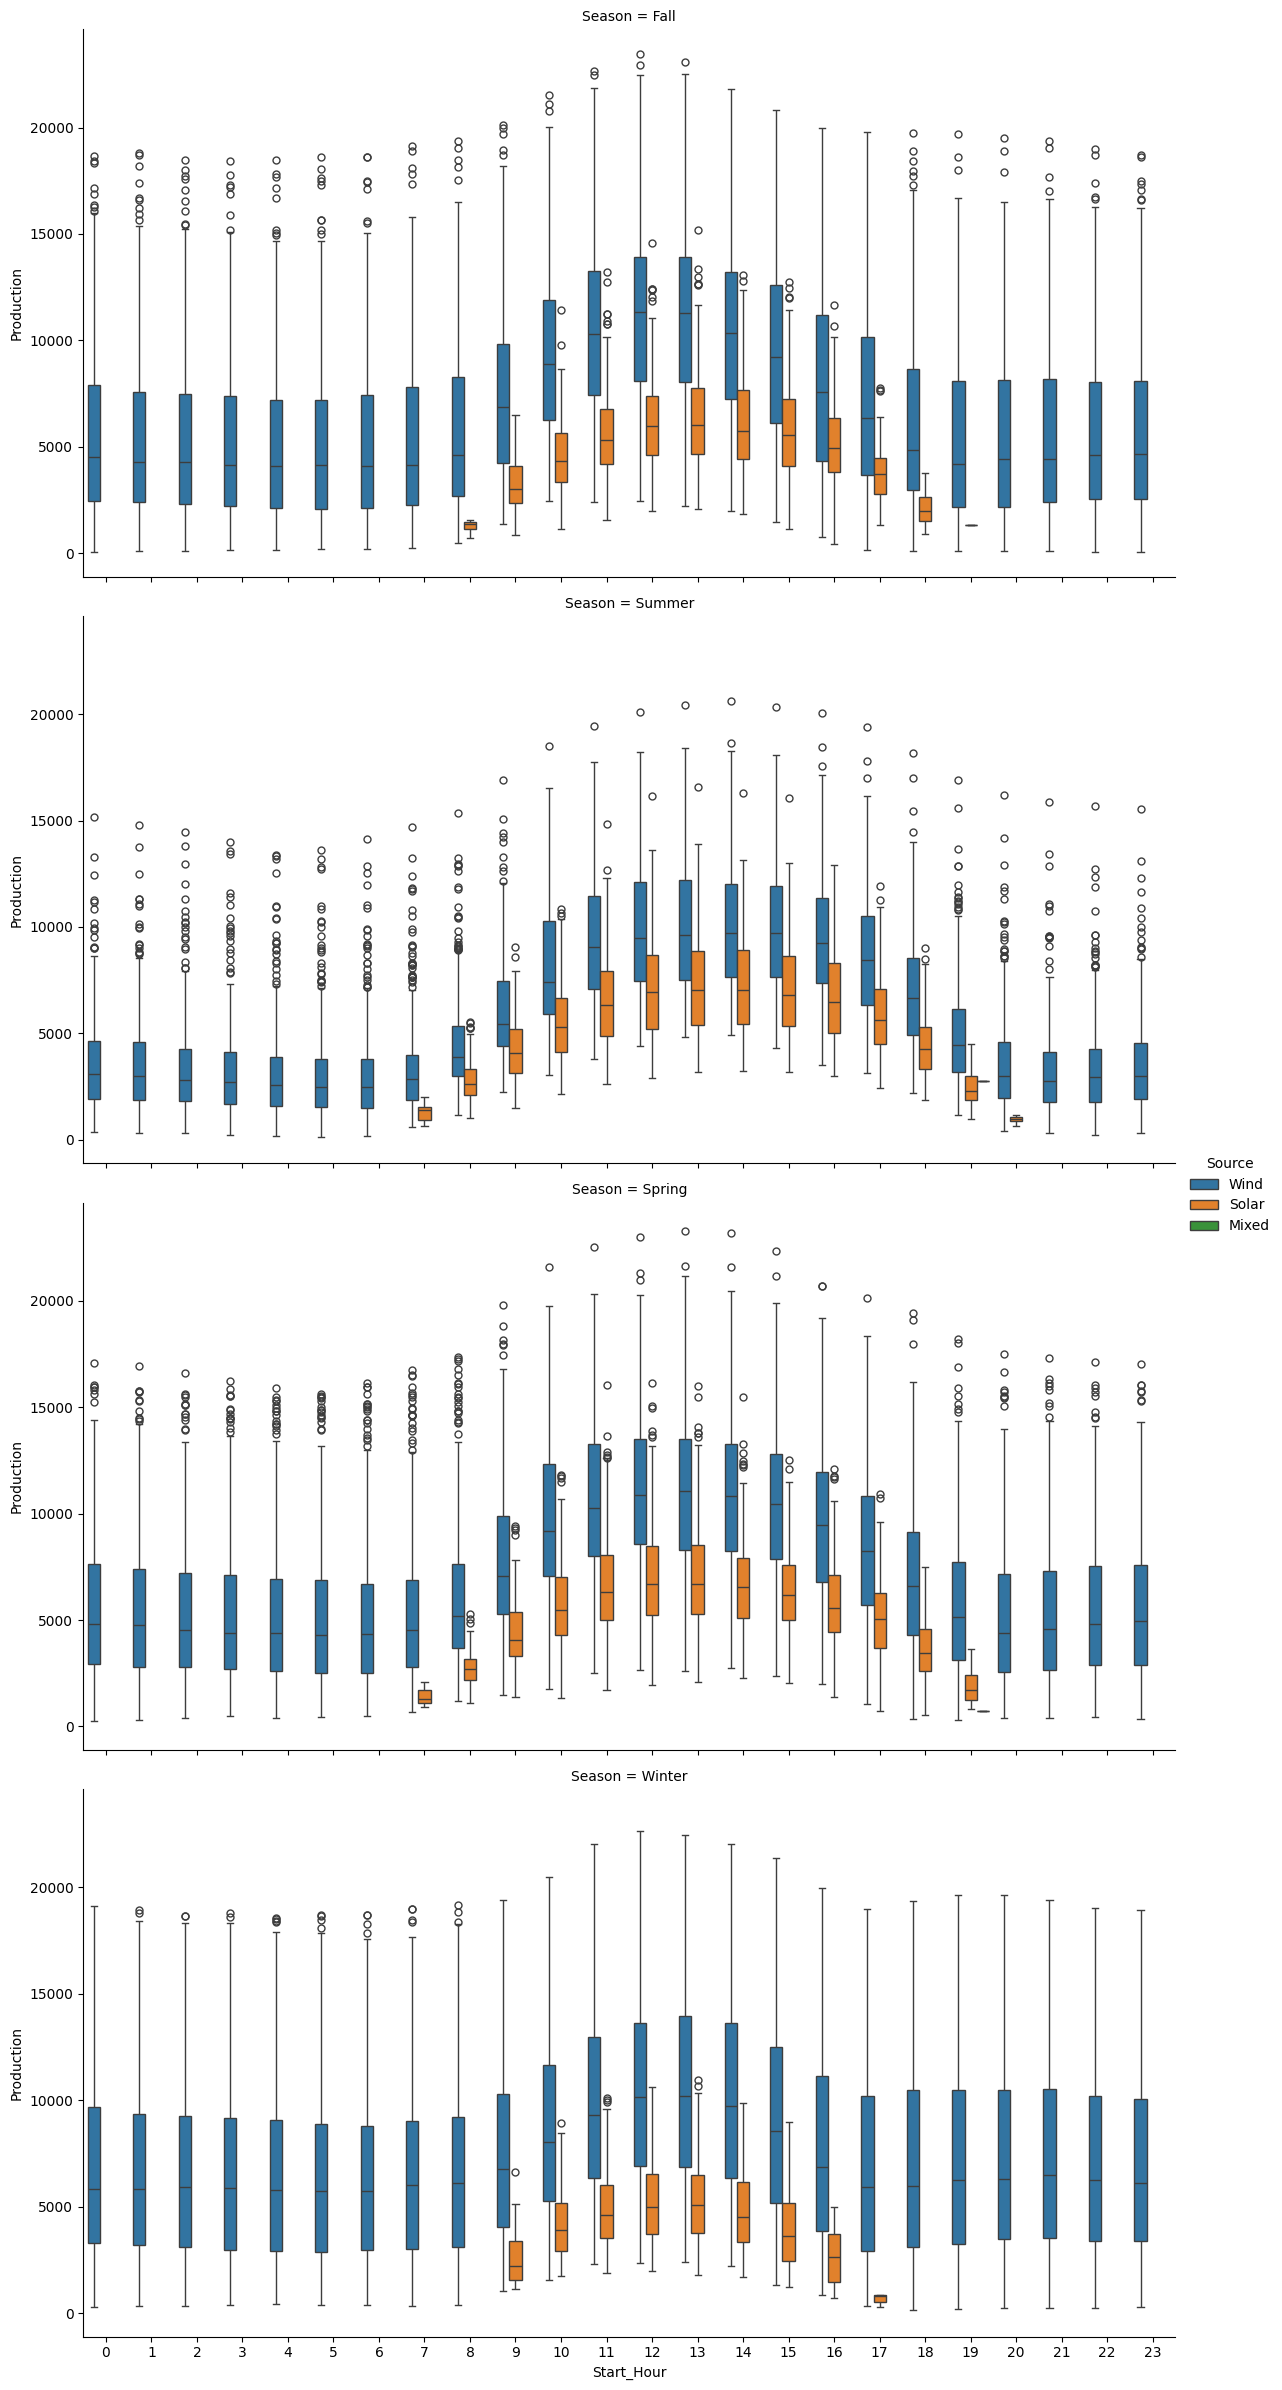

In [22]:
sns.catplot(data = energy, x = 'Start_Hour', y = 'Production', hue = 'Source', col = 'Season', kind = 'box', height = 6, aspect = 2, col_wrap = 1, sharey = True)
plt.show()

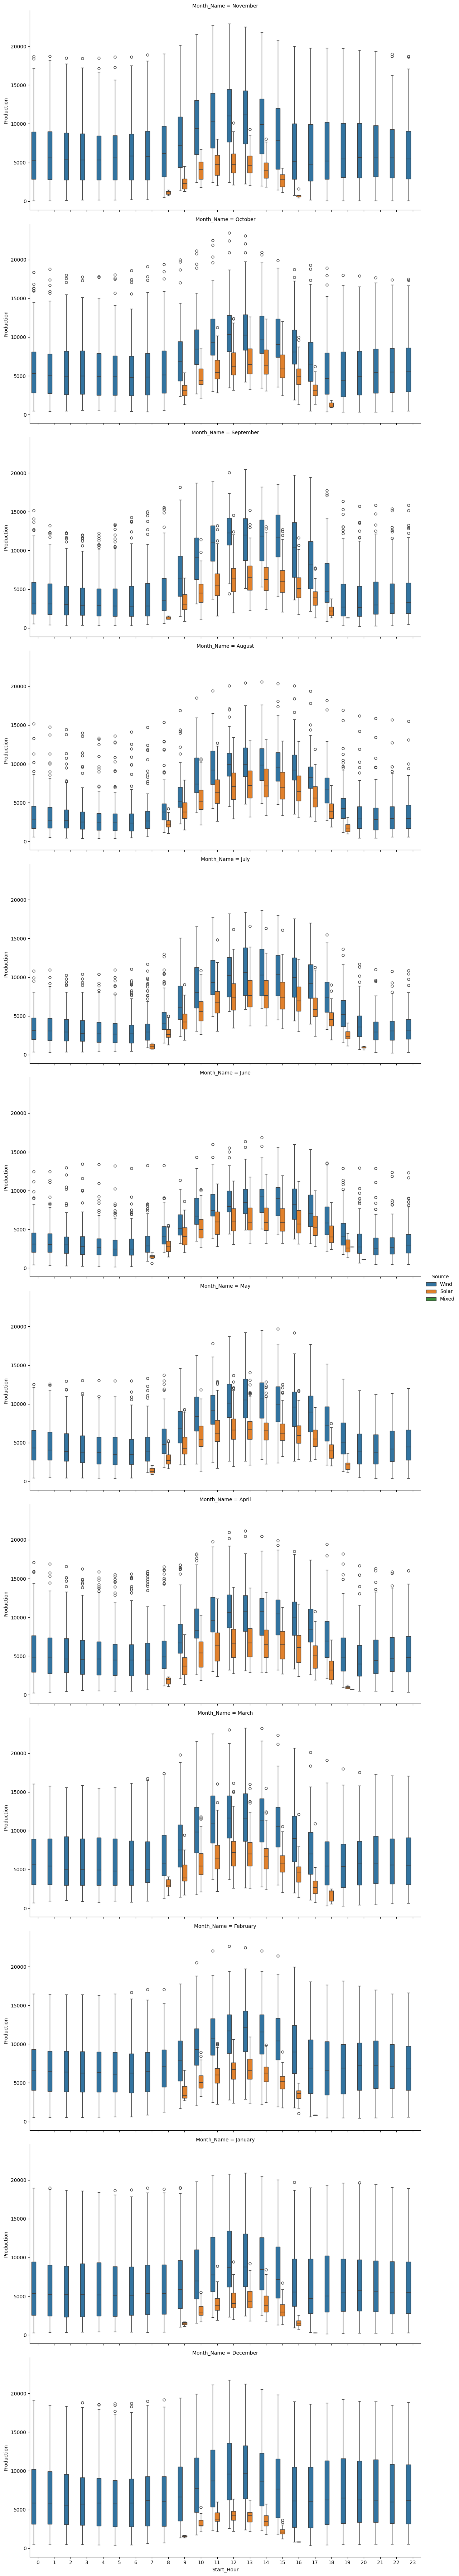

In [23]:
sns.catplot(data = energy, x = 'Start_Hour', y = 'Production', hue = 'Source', col = 'Month_Name', kind = 'box', height = 6, aspect = 2, col_wrap = 1, sharey = True)
plt.show()

## Report of Multivariate Analysis 

1) The hypothesis of Day_Name and Day_of_Year is useless has been proven 
2) The Start_Hour and End_Hour shows as interesting sight of production being at max at Noon or can say 1pm to 2pm 
3) The Season and Month also plays a key role 
4) The Wind is the major source of contribution regardless of the season or time in this dataset.
5) From the last graph we can say March to August the Solar Energy Production was somewhat good and can be said close to wind energy production.

In [24]:
energy[energy['End_Hour'] < energy['Start_Hour']]

,Date,Start_Hour,End_Hour,Source,Day_of_Year,Day_Name,Month_Name,Season,Production
3,11/30/2025,23,0,Wind,334,Sunday,November,Fall,6120
35,11/29/2025,23,0,Wind,333,Saturday,November,Fall,5416
60,11/28/2025,23,0,Wind,332,Friday,November,Fall,5812
78,11/27/2025,23,0,Wind,331,Thursday,November,Fall,9223
100,11/26/2025,23,0,Wind,330,Wednesday,November,Fall,4192
...,...,...,...,...,...,...,...,...,...
51745,1/5/2020,23,0,Wind,5,Sunday,January,Winter,2129
51785,1/4/2020,23,0,Wind,4,Saturday,January,Winter,1931
51796,1/3/2020,23,0,Wind,3,Friday,January,Winter,3798
51822,1/2/2020,23,0,Wind,2,Thursday,January,Winter,6857


In [25]:
energy['Duration'] = (energy['End_Hour'] - energy['Start_Hour']) % 24
energy['Duration'].max()

np.int64(1)

In [26]:
energy.drop(['Day_of_Year', 'Day_Name', 'Duration'], axis = 1, inplace = True)
energy

,Date,Start_Hour,End_Hour,Source,Month_Name,Season,Production
0,11/30/2025,21,22,Wind,November,Fall,5281
1,11/30/2025,18,19,Wind,November,Fall,3824
2,11/30/2025,16,17,Wind,November,Fall,3824
3,11/30/2025,23,0,Wind,November,Fall,6120
4,11/30/2025,6,7,Wind,November,Fall,4387
...,...,...,...,...,...,...,...
51859,1/1/2020,4,5,Wind,January,Winter,2708
51860,1/1/2020,18,19,Wind,January,Winter,1077
51861,1/1/2020,7,8,Wind,January,Winter,2077
51862,1/1/2020,14,15,Solar,January,Winter,1783


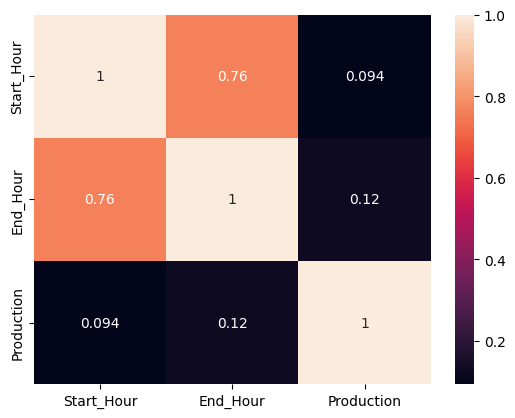

In [27]:
sns.heatmap(data = energy.select_dtypes(include=['int64']).corr(), annot = True)
plt.show()

In [28]:
energy.Source.value_counts()

Source
Wind     42484
Solar     9378
Mixed        2
Name: count, dtype: int64

In [29]:
energy.Month_Name.value_counts()

Month_Name
October      4470
August       4464
May          4464
July         4464
January      4464
March        4458
September    4320
November     4320
April        4320
June         4320
February     4080
December     3720
Name: count, dtype: int64

In [30]:
energy.Season.value_counts()

Season
Summer    13248
Spring    13242
Fall      13110
Winter    12264
Name: count, dtype: int64

In [31]:
new = energy.groupby(by=['Start_Hour', 'Season'])['Production'].mean()
new

Start_Hour  Season
0           Fall      5488.932234
            Spring    5538.724638
            Summer    3531.307971
            Winter    6808.774951
1           Fall      5349.613553
                         ...     
22          Winter    7021.639922
23          Fall      5593.637363
            Spring    5538.710145
            Summer    3510.096014
            Winter    6935.945205
Name: Production, Length: 96, dtype: float64

In [32]:
new = pd.DataFrame(new).reset_index()
new

,Start_Hour,Season,Production
0,0,Fall,5488.932234
1,0,Spring,5538.724638
2,0,Summer,3531.307971
3,0,Winter,6808.774951
4,1,Fall,5349.613553
...,...,...,...
91,22,Winter,7021.639922
92,23,Fall,5593.637363
93,23,Spring,5538.710145
94,23,Summer,3510.096014


In [33]:
new = new.pivot(index = 'Start_Hour', columns = 'Season', values = 'Production')
new

Season,Fall,Spring,Summer,Winter
Start_Hour,,,,
0,5488.932234,5538.724638,3531.307971,6808.774951
1,5349.613553,5441.958333,3455.791667,6696.798434
2,5256.471014,5291.595238,3329.695652,6586.898239
3,5116.571429,5199.422101,3186.065217,6501.982387
4,5044.769231,5106.936594,3047.472826,6458.013699
5,5056.109890,5036.646739,2971.353261,6454.500978
6,5131.296703,5017.085145,2967.349638,6485.379648
7,5308.525641,5226.731884,3246.206522,6685.272016
8,5674.423077,5695.798913,3830.313406,6870.853229


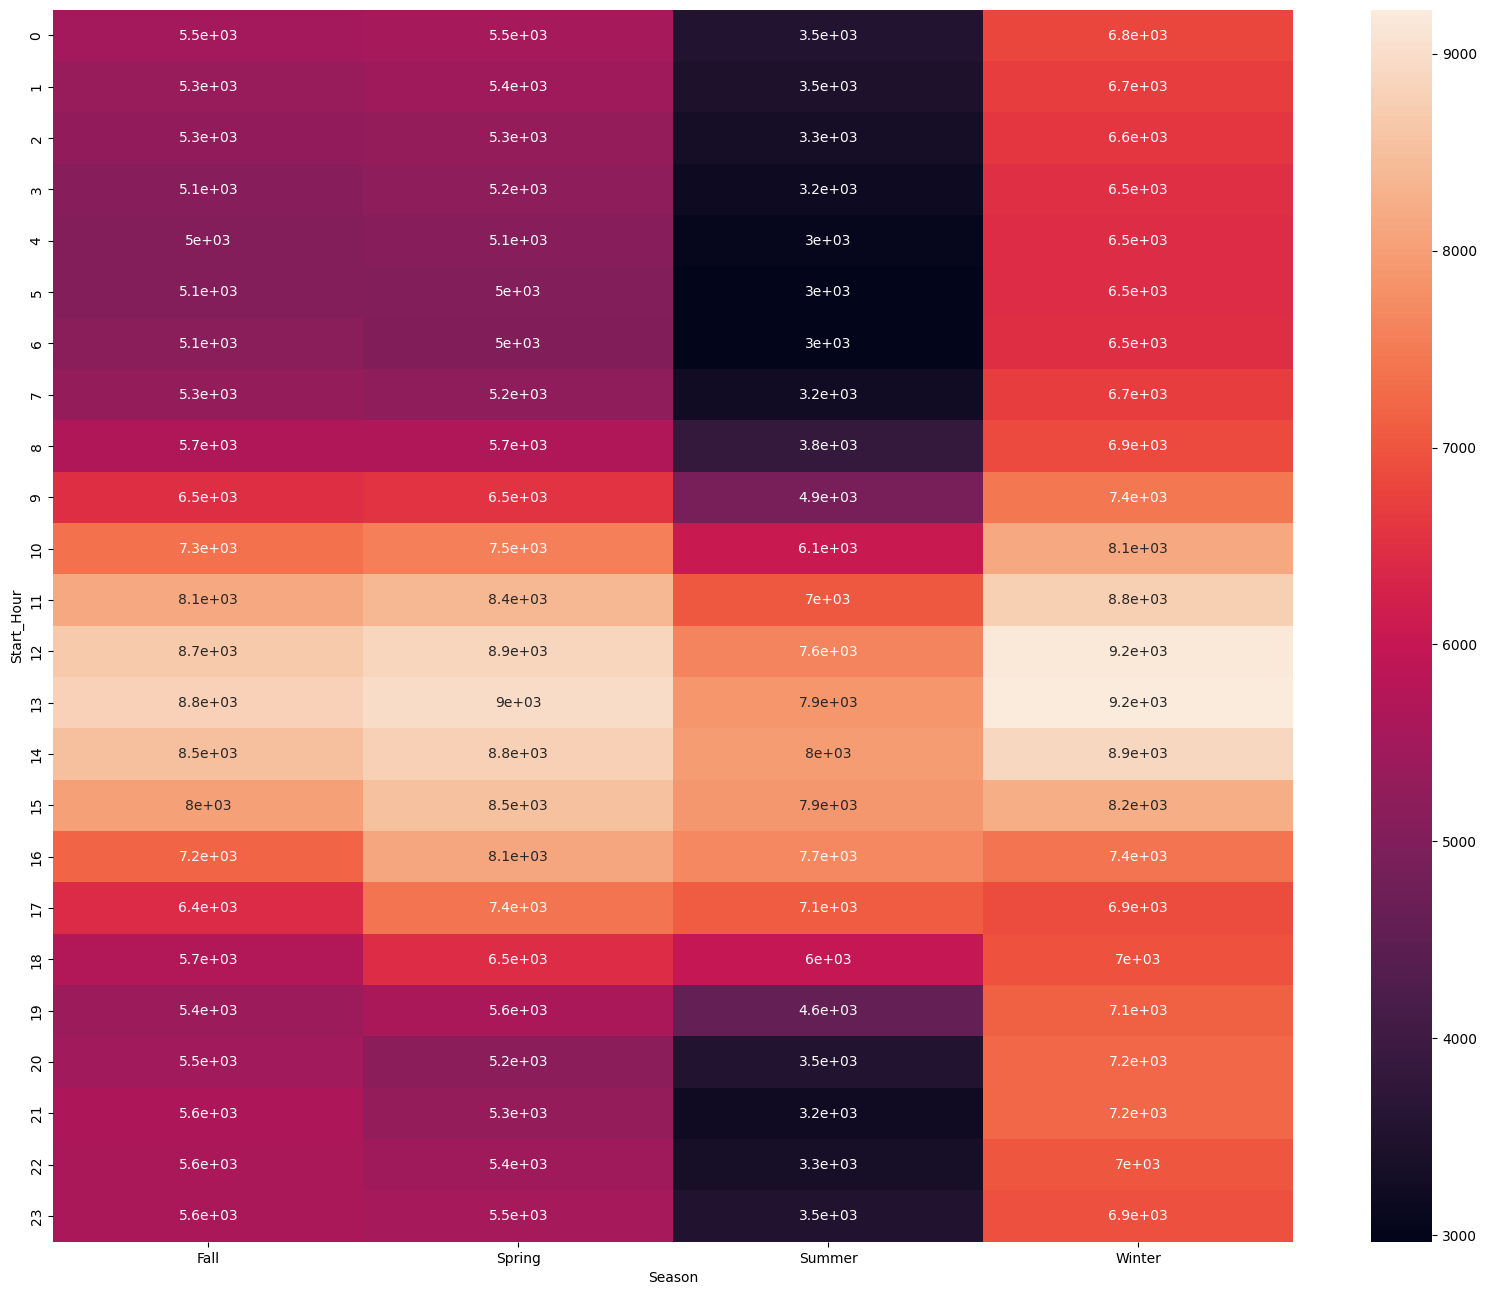

In [34]:
plt.figure(figsize = (20, 16))
sns.heatmap(data = new,  annot= True)
plt.show()

## Report 

1) The Production is highest from 11am to 3pm  
2) The Start_Hour and End_Hour is very important for production


In [35]:
energy

,Date,Start_Hour,End_Hour,Source,Month_Name,Season,Production
0,11/30/2025,21,22,Wind,November,Fall,5281
1,11/30/2025,18,19,Wind,November,Fall,3824
2,11/30/2025,16,17,Wind,November,Fall,3824
3,11/30/2025,23,0,Wind,November,Fall,6120
4,11/30/2025,6,7,Wind,November,Fall,4387
...,...,...,...,...,...,...,...
51859,1/1/2020,4,5,Wind,January,Winter,2708
51860,1/1/2020,18,19,Wind,January,Winter,1077
51861,1/1/2020,7,8,Wind,January,Winter,2077
51862,1/1/2020,14,15,Solar,January,Winter,1783


In [36]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(energy.drop(columns = ['Production']), energy['Production'], test_size=0.2, random_state=42)
X_train

,Date,Start_Hour,End_Hour,Source,Month_Name,Season
17023,12/22/2023,7,8,Wind,December,Winter
2290,8/27/2025,2,3,Wind,August,Summer
31067,5/16/2022,16,17,Solar,May,Spring
10490,9/19/2024,19,20,Wind,September,Fall
46568,8/8/2020,8,9,Wind,August,Summer
...,...,...,...,...,...,...
11284,8/17/2024,9,10,Solar,August,Summer
44732,10/24/2020,5,6,Wind,October,Fall
38158,7/25/2021,11,12,Wind,July,Summer
860,10/26/2025,2,3,Wind,October,Fall


In [41]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer

ohe = OneHotEncoder(sparse_output=False, drop='first')
oe = OrdinalEncoder(categories=[['Winter', 'Spring', 'Summer', 'Fall']])

ct  =ColumnTransformer(transformers=[
    ('ohe', ohe, ['Month_Name', 'Source']),
    ('oe', oe, ['Season'])
], remainder='passthrough')

X_train_encoded = pd.DataFrame(ct.fit_transform(X_train), columns=ct.get_feature_names_out())
X_train_encoded

,ohe__Month_Name_August,ohe__Month_Name_December,ohe__Month_Name_February,ohe__Month_Name_January,ohe__Month_Name_July,ohe__Month_Name_June,ohe__Month_Name_March,ohe__Month_Name_May,ohe__Month_Name_November,ohe__Month_Name_October,ohe__Month_Name_September,ohe__Source_Solar,ohe__Source_Wind,oe__Season,remainder__Date,remainder__Start_Hour,remainder__End_Hour
0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,12/22/2023,7,8
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0,8/27/2025,2,3
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,5/16/2022,16,17
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,3.0,9/19/2024,19,20
4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0,8/8/2020,8,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41486,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,2.0,8/17/2024,9,10
41487,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,3.0,10/24/2020,5,6
41488,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0,7/25/2021,11,12
41489,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,3.0,10/26/2025,2,3
